# DASC 512: Homework 4

# Student Name: Mitchell Scott

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.stats.api as sms
import statsmodels.graphics.api as smg
import statsmodels.formula.api as smf
theme='dark'

import os
from DASC500.stats.distribution.distribution_analyzer import DistributionAnalyzer
from DASC500.utilities.get_top_level_module import get_project_root_jupyter
ROOT = get_project_root_jupyter()
DATA_FOLDER = os.path.join(ROOT, 'data/DASC512/Homework/4')
analyzer = DistributionAnalyzer()

Starting from: c:\Users\amber\Documents\Mitchell\school\2025\DASC500\DASC500\src\DASC500\DASC512\homework
Found indicator: pyproject.toml at c:\Users\amber\Documents\Mitchell\school\2025\DASC500\DASC500


In [4]:
def set_style(theme='dark'):
    if theme == 'dark':
        sns.set_theme(style='ticks', context='notebook', rc={'axes.facecolor':'black', 'figure.facecolor':'black', 'text.color':'white',
                      'xtick.color':'white', 'ytick.color':'white', 'axes.labelcolor':'white', 'axes.grid':False, 'axes.edgecolor':'white'})
    else:
        sns.set_theme(style='ticks', context='notebook')
set_style(theme)

# Problem 1

Use the file `BattingAverages2023.csv`, containing batting averages for all players with at least 100 at bats for the 2023 season, for the following questions. Assume this is a random sample rather than a census.

In [5]:
# Import data
batting_df = pd.read_csv(os.path.join(DATA_FOLDER, 'BattingAverages2023.csv'))
batting_avg = batting_df['BattingAvg'].dropna()


***

## 1A

Are the batting averages data (`BattingAvg`) normally distributed? Use both graphical and analytical methods to make your argument.

In [ ]:
# Analytical Methods1
stats_summary = analyzer.calculate_statistics(batting_avg)
print(f"Descriptive Statistics: Skewness = {stats_summary['skewness']:.3f}, Kurtosis = {stats_summary['kurtosis']:.3f}")

normality_tests = analyzer.hypothesis_test(batting_avg, test_type='normality')
for test, results in normality_tests.items():
    for result, value in results.items():
        print(f"{test} {result}: {value}")


Descriptive Statistics: Skewness = -0.337, Kurtosis = 0.833
shapiro_wilk statistic: 0.98751238284694
shapiro_wilk p_value: 0.0013754864190648104
ks_normality statistic: 0.049380041253123785
ks_normality p_value: 0.26145515855903956
anderson_darling statistic: 1.2059834316538627
anderson_darling critical_values: [0.571 0.65  0.78  0.909 1.082]
anderson_darling significance_levels: [15.  10.   5.   2.5  1. ]
jarque_bera statistic: 19.61580554532972
jarque_bera p_value: 5.50151050775146e-05
Shapiro-Wilk Test: p-value = 1.38e-03
Jarque-Bera Test: p-value = 5.50e-05


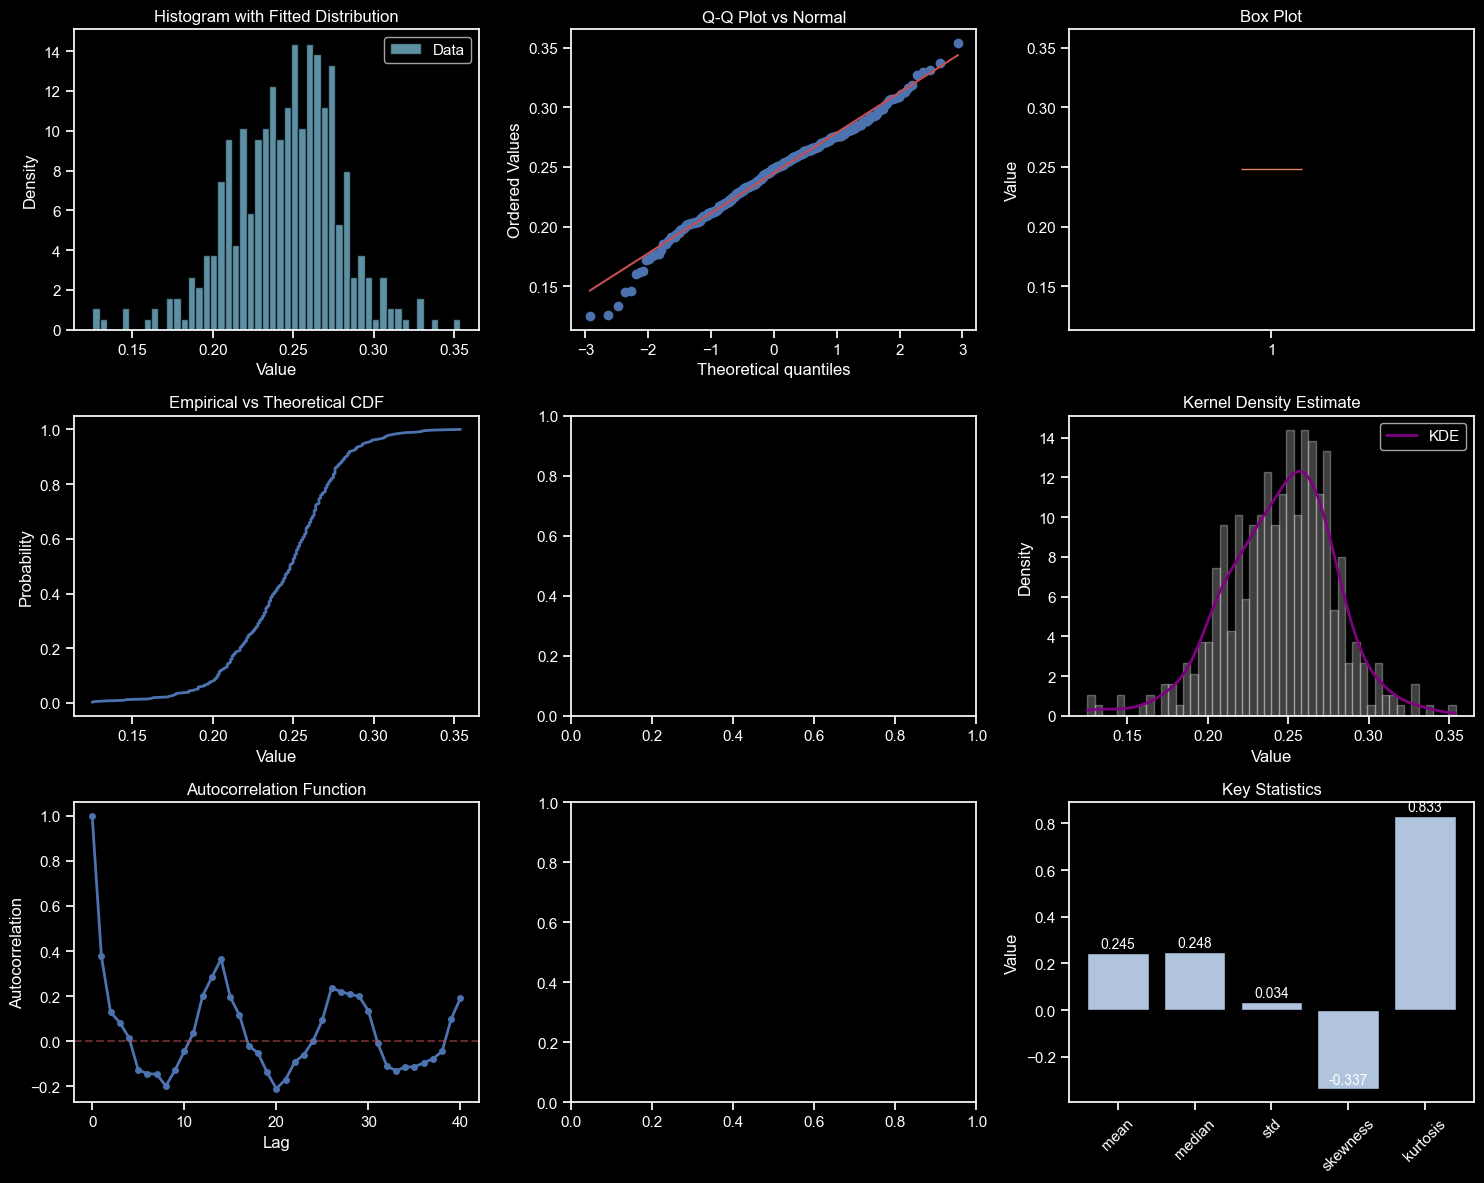

In [7]:
# Graphical Methods
analyzer.plot_distribution(batting_avg)

🟢 *You should answer this question in the Markdown block below. Use the code block as needed.*

BLUF: The batting average data is not normal distributed. It is a bit lopsided with a tail of lower-performing players kewing the data to the left.
            
Hypotheses: *State your null and alternative hypotheses.*  \
Null: The batting average data is drawn from a normal distribution.  \
Alternative: The batting average data is not drawn from a normal distribution.

Type of test: *What tests (both analytical and graphical) did you use?*  \
Analytical: I used the Shapiro-Wilk.  \
Graphical: Histogram and Q-Q plots were used.

Significance: *What significance did you choose to use? Why?*  \
I chose the $\alpha=0.05$ significance level because this is seems like a standard value to help balanace out the likelihood of making Type I and Type II mistakes.

P value: *What was the p-value of your analytical test?*  \
Shapiro-Wilk: $p=0.00138$

Conclusion: *Formally state your conclusion (i.e., reject or fail to reject the null hypothesis)*  \
I reject my null hypothesis in favor of accepting my alternative hypothesis. Therefore, the data for batting averages is not normal.

*Feel free to add further discussion if you find something interesting in this question or others.*

🔴

#### Hint

Remember this is just part of the solution, to give you a sanity check on your answer. You can dive deeper into the data, and you should not limit yourself to graphical results.

Also consider your sample size. What is the best test to use here?

***

## 1B

Is the mean value of batting averages at least .250? Perform a test to find out. Use $\alpha=0.05$ for your test. You may assume the underlying distribution is normal for this and below problems regardless of your conclusion in 1A.

In [8]:
# Run your test and calculate the associated values and intervals.
mu0_batting = 0.250
alpha_batting = 0.05
# H0: mu <= 0.250, Ha: mu > 0.250
test_b = analyzer.hypothesis_test(batting_avg, test_type='one_sample_t', mu=mu0_batting, alternative='greater')
print(f"One-Sample t-test (alternative='greater'):")
print(f"  t-statistic = {test_b['one_sample_t']['statistic']:.3f}")
print(f"  p-value = {test_b['one_sample_t']['p_value']:.3f}")

One-Sample t-test (alternative='greater'):
  t-statistic = -2.962
  p-value = 0.998


🟢 *You should answer this question in the Markdown block below. Use the code block as needed.*

BLUF: The data does support the claim that the batting averages are at least 0.250.
            
Hypotheses: *State your null and alternative hypotheses.*  \
Null: The true mean batting average is less than or equal to 0.250 ($\mu≤0.250$).  \
Alternative: The true mean batting average is greater than 0.250 ($\mu>0.250$).

Type of test: *What tests (both analytical and graphical) did you use?*  \
I used a one-sample t-test because I'm comparing the average of a single group against a specific number (0.250).

Significance: *What significance did you choose to use? Why?*  \
I used the significance level of $\alpha=0.05$ because this seems like a standard, widely used and accepted value that helps to minimize Type I and Type II error.

P value: *What was the p-value of your analytical test?*  \
$p=0.998$

Conclusion: *Formally state your conclusion (i.e., reject or fail to reject the null hypothesis)*  \
I fail to reject the null hypothesis because there is not enough evidence to say that the batting average is greater than 0.250.

*Feel free to add further discussion if you find something interesting in this question or others.*

***

## 1C

Was there a difference between batting averages in the National League (NL) and American League(AL) (column `League`)? Use $\alpha=0.05$ for your test.

In [22]:
# Run your test and calculate the associated values and intervals.
print("\n--- 1(c) Difference between NL and AL Batting Averages ---")
nl_avg = batting_df[batting_df['League'] == 'NL']['BattingAvg'].dropna()
al_avg = batting_df[batting_df['League'] == 'AL']['BattingAvg'].dropna()

# First, test for equality of variances
levene_test = analyzer.hypothesis_test(nl_avg, test_type='levene', data2=al_avg)
levene_f_stat = levene_test['levene']['statistic']
levene_p_val = levene_test['levene']['p_value']
print(f"Levene's Test for Equal Variances: f-statistic = {levene_p_val:.3f}")
print(f"Levene's Test for Equal Variances: p-value = {levene_p_val:.3f}")
# Based on p-value, decide if variances are equal
equal_var_flag = levene_p_val > alpha_batting
print(f"Assuming equal variances: {equal_var_flag}")

# Perform two-sample t-test
test_c = analyzer.hypothesis_test(nl_avg, test_type='two_sample_t', data2=al_avg, equal_var=equal_var_flag)
print("\nTwo-Sample t-test Results:")
print(f"  NL Mean: {nl_avg.mean():.3f}, AL Mean: {al_avg.mean():.3f}")
print(f"  t-statistic = {test_c['two_sample_t']['statistic']:.3f}")
print(f"  p-value = {test_c['two_sample_t']['p_value']:.3f}")

# Manually calculate 95% CI for the difference in means
mean_diff = nl_avg.mean() - al_avg.mean()
n1, n2 = len(nl_avg), len(al_avg)
s1, s2 = nl_avg.std(), al_avg.std()
# Pooled standard deviation
sp = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
# Standard error of the difference
se_diff = sp * np.sqrt(1/n1 + 1/n2)
# T-critical value
t_crit = stats.t.ppf(1 - alpha_batting/2, df=n1+n2-2)
# Margin of error
moe = t_crit * se_diff
ci_lower, ci_upper = mean_diff - moe, mean_diff + moe
print(f"95% CI for difference in means (NL - AL): ({ci_lower:.4f}, {ci_upper:.4f})")



--- 1(c) Difference between NL and AL Batting Averages ---
Levene's Test for Equal Variances: f-statistic = 0.912
Levene's Test for Equal Variances: p-value = 0.912
Assuming equal variances: True

Two-Sample t-test Results:
  NL Mean: 0.245, AL Mean: 0.245
  t-statistic = 0.142
  p-value = 0.887
95% CI for difference in means (NL - AL): (-0.0061, 0.0070)


🟢 *You should answer this question in the Markdown block below. Use the code block as needed.*

BLUF: The batting averages for the NL and AL have roughly the same means and the same variances with a fairly negligible difference in means at the 95% confidence interval.

Hypotheses:  \
Levene Test:  \
Null: The sample variances for the batting averages of the AL and NL are equal ($\sigma_{AL} = \sigma_{NL}$)  \
Alternative: The sample variances for the batting averages of the AL and NL are not equal ($\sigma_{AL} \neq \sigma_{NL}$)  \

Two-Sample T-Test:  \
Null:  The true mean of the batting averages for the AL and NL are equal ($\mu_{AL} = \mu_{NL}$)
Alternative:  The true-mean of the batting averages for the AL and NL are not equal ($\mu_{AL} \neq \mu_{NL}$)\

Type of test: Levene Test to verify if the variance of each variance of each group NL and AL is equal and a two-sample t-test to compare the NL and AL batting averages.

Significance: I chose to use a significance of $\alpha=0.05$ again for both tests again because of broad applicability and balance of Type I and Type II error.

Test statistic:  \
Levene Test: 0.012  \
Two-Sample 0.142

P value: 
Levene Test: p-value=0.912  \
Two-Sample t-test: p-value=0.887

Conclusion:  \
Levene Test: Not enough evidence to reject the null hypothesis and accept the alternative hypothesis. Therefore, we can assume the sample variances for the batting averages with the NL and AL are equal.  \
Two-Sample T-Test: Not enough evidence to reject the null hypothesis and accept the alternative hypothesis. Therefore, we can assume the sample batting average means are equal for the NL and AL.

Confidence interval: At the 95% confidence level, I can say the confidence interval for the difference in the means is:  \
[-0.0061 - 0.0070]

***

# Problem 2

A researcher studying true body temperature in adult humans collected the data in \texttt{BodyTemp.csv} in degrees Fahrenheit.

In [10]:
# Import data
bodytemp_df = pd.read_csv(os.path.join(DATA_FOLDER, 'BodyTemp.csv'))
body_temp = bodytemp_df['BodyTemp'].dropna()


***

## 2A

Is the body temperature normally distributed? Use graphical and analytical methods to make your argument.

In [11]:
# Analytical test
body_stats_summary = analyzer.calculate_statistics(body_temp)
print(f"Descriptive Statistics: Skewness = {body_stats_summary['skewness']:.3f}, Kurtosis = {body_stats_summary['kurtosis']:.3f}")

body_normality_tests = analyzer.hypothesis_test(body_temp, test_type='normality')
print(f"Shapiro-Wilk Test: p-value = {body_normality_tests['shapiro_wilk']['p_value']:.3f}")
print(f"Jarque-Bera Test: p-value = {body_normality_tests['jarque_bera']['p_value']:.3f}")


Descriptive Statistics: Skewness = -0.004, Kurtosis = 0.705
Shapiro-Wilk Test: p-value = 0.233
Jarque-Bera Test: p-value = 0.260


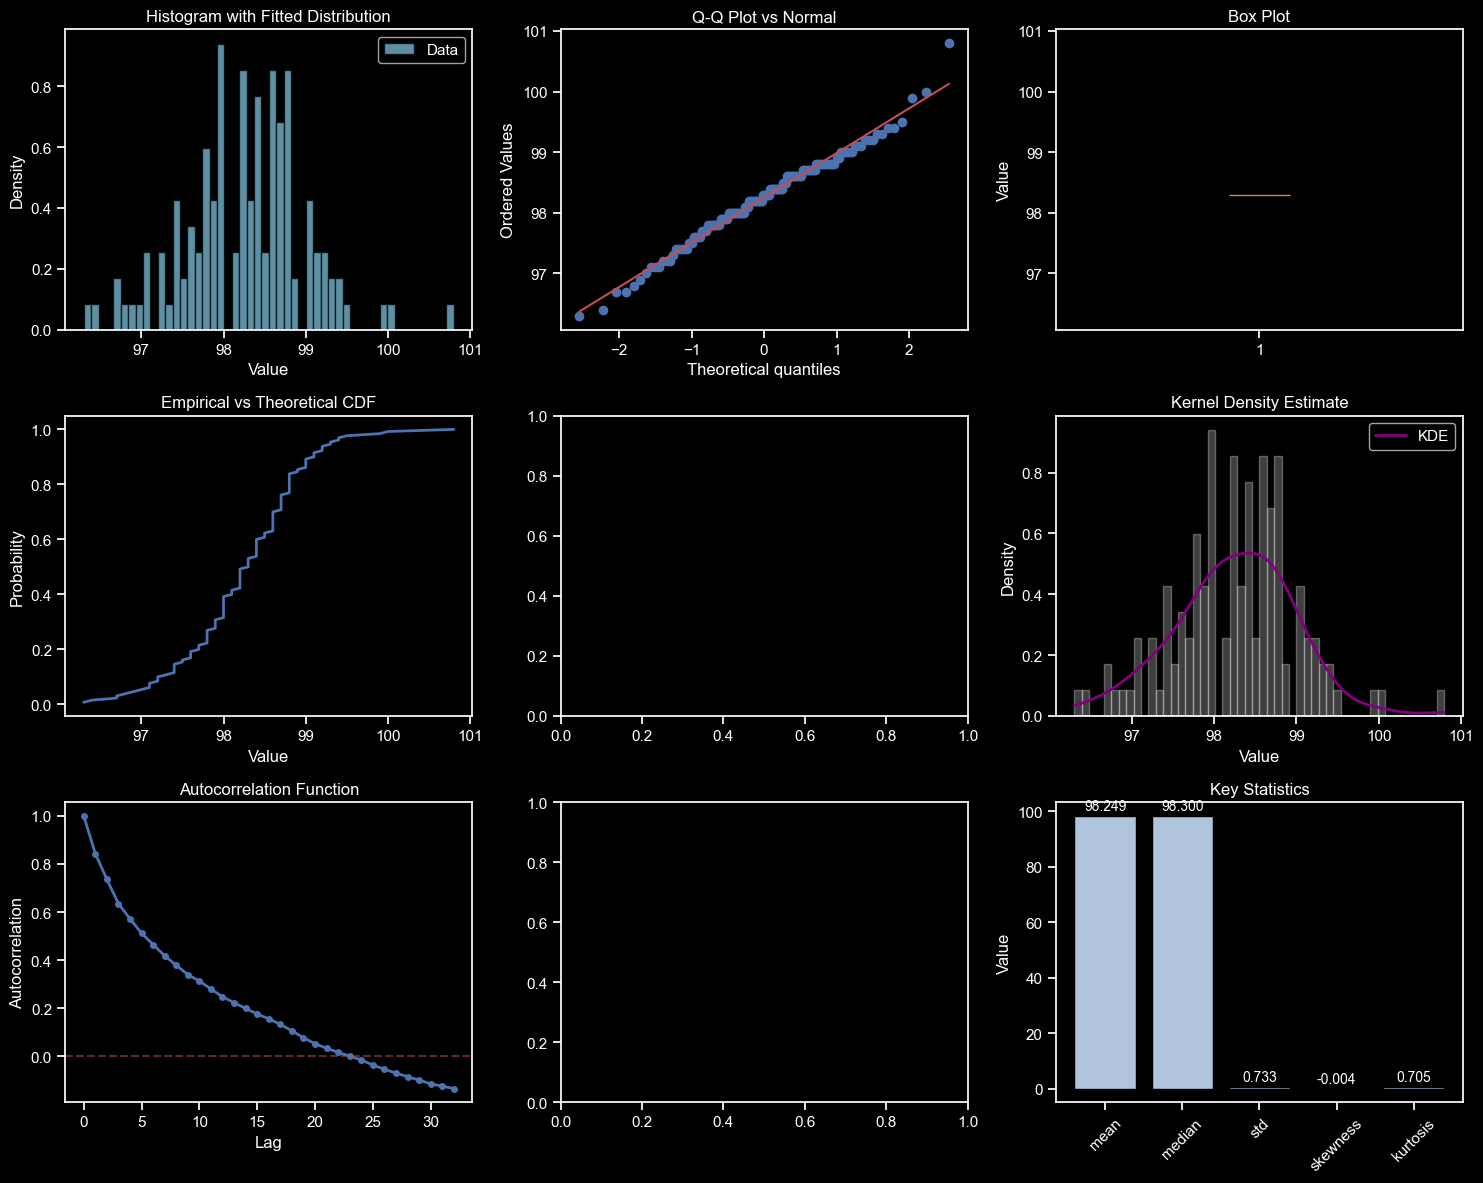

In [12]:
# Graphical assessment
analyzer.plot_distribution(body_temp)

🟢 *You should answer this question in the Markdown block below. Use the code block as needed.*

BLUF: The data is roughly normal with some outliers (primarily on the high-end).

Hypotheses:  \
Null: The data is normally distributed. \
Alternative:  The data is not normally distributed.  

Type of test:  \
For testing normality with the given data that has a relatively small sample size (n=130) I will rely on the Shapiro-Wilk normality test.

Significance: 
I chose to use the significance level of 95% (i.e. $\alpha=0.05$)

P value: 0.223

Conclusion: Not enough evidence to reject the null hypothesis and accept the alternative hypothesis. Therefore, the data is normally distributed at the 95% confidence level.

🔴

#### Hint

Remember this is just part of the solution, to give you a sanity check on your answer. You can dive deeper into the data, and you should not limit yourself to graphical results.

Also consider your sample size. What is the best test to use here?

***

## 2B

Is the mean body temperature equal to 98.6? (Remember the instructions --- run a test!)

In [13]:
# Run your test and calculate associated values and intervals
mu0_temp = 98.6
alpha_temp = 0.05
# H0: mu = 98.6, Ha: mu != 98.6
test_2b = analyzer.hypothesis_test(body_temp, test_type='one_sample_t', mu=mu0_temp, alternative='two-sided')
print(f"One-Sample t-test (two-sided):")
print(f"  Sample Mean = {body_temp.mean():.3f}")
print(f"  t-statistic = {test_2b['one_sample_t']['statistic']:.3f}")
print(f"  p-value = {test_2b['one_sample_t']['p_value']:.2e}")

# Calculate 95% CI using the class method
ci_2b = analyzer.confidence_interval(body_temp, confidence=1-alpha_temp, parameter='mean')
print(f"95% CI for mean body temp: ({ci_2b['confidence_interval'][0]:.3f}, {ci_2b['confidence_interval'][1]:.3f})")


One-Sample t-test (two-sided):
  Sample Mean = 98.249
  t-statistic = -5.455
  p-value = 2.41e-07
95% CI for mean body temp: (98.122, 98.376)


🟢 *You should answer this question in the Markdown block below. Use the code block as needed.*

BLUF: The sample mean of body temperatures is not 98.6.

Hypotheses:  \
Null: The sample of mean of the body temperatures is 98.6 ($\mu = 98.6$).  \
Alternative: The sample mean is not 98.6 ($\mu \neq 98.6$)

Type of test: To test if the sample mean of the body temperatures is 98.6, I chose to use a one-sample t-test. This is because I am comparing the sample mean to a single value.

Significance: I chose to use a 95% confidence level here as it is a standard and balance type I and type II error.

Test statistic: -5.455

P value: 2.41e-07

Conclusion: We reject the null hypothesis and accept the alternative hypothesis. Therefore, the sample mean is not 98.6.

Confidence interval: At the 95% confidence level, the mean body temperature for the provided sample is:  \
[98.1 - 98.4]

***

## 2C

For the $\alpha$ you selected, what is the power to detect a difference of 0.2 degrees? Assume the population variance is equal to the sample variance.

Remember that effect size is $\frac{\text{Difference to Detect}}{\sigma}$. See the progress check for examples.

In [25]:
# Define effect_size and calculate power
# Be sure you use the function for a single sample!
diff_to_detect = 0.2
s_temp = body_temp.std()
n_temp = len(body_temp)
effect_size_temp = diff_to_detect / s_temp
print(f"Inputs for Power Analysis:")
print(f"  Alpha = {alpha_temp}, n = {n_temp}, StDev = {s_temp:.3f}, Effect Size = {effect_size_temp:.3f}")

power_results = analyzer.power_analysis(
    effect_size=effect_size_temp,
    alpha=alpha_temp,
    n=n_temp,
    test_type="one_sample_t"
)

print(f"\nPower Analysis Results:")
print(f"  Power to detect a difference of {diff_to_detect} degrees = {power_results['power']:.4f}")

Inputs for Power Analysis:
  Alpha = 0.05, n = 130, StDev = 0.733, Effect Size = 0.273

Power Analysis Results:
  Power to detect a difference of 0.2 degrees = 0.8701


🟢 *You should answer this question in the Markdown block below. Use the code block as needed.*

With the given study parameters ($\alpha$ = 0.05, n = 130, $\sigma$ = 0.733, effect size = 0.273), the power to detect a clinically meaningful difference of 0.2 from the hypothesized mean of 98.6 is 0.87 (87%).

This indicates that if the true population mean body temperature actually differs from 98.6 by 0.2 or more, this study has an 87% probability of correctly detecting this difference and rejecting the null hypothesis. In other words, there is only a 13% chance of committing a Type II error (failing to detect a true difference of 0.2 when one exists).

***

## 2D

Create a plot showing how $\alpha$ (x-axis) affects the power to detect a difference of 0.2 degrees (y-axis). 

🟢 **Show your solution code below this block**

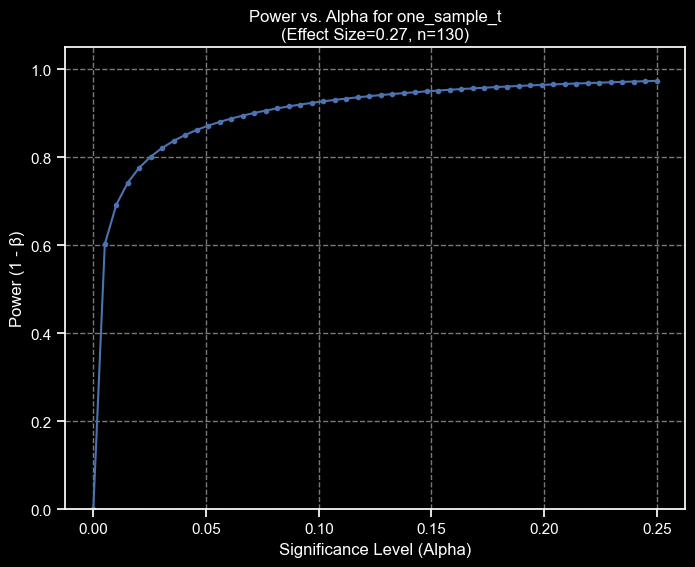

In [17]:
# Create your plot! Be careful with functions that create this plot and haven't been taught.
# Those might not function as you expect them to.
# Again, be sure you use the function for a single sample!
analyzer.plot_power_vs_alpha(effect_size=effect_size_temp, n=n_temp, test_type='one_sample_t')


🔴

#### Hint

***

## 2E

Is there a difference between body temperatures of men and women? Run a hypothesis test to find out.

In [24]:
# Run your test and calculate associated value and intervals
male_temp = bodytemp_df[bodytemp_df['Gender'] == 'male']['BodyTemp'].dropna()
female_temp = bodytemp_df[bodytemp_df['Gender'] == 'female']['BodyTemp'].dropna()

# First, test for equality of variances
levene_test_temp = analyzer.hypothesis_test(male_temp, test_type='levene', data2=female_temp)
levene_p_val_temp = levene_test_temp['levene']['p_value']
print(f"Levene's Test for Equal Variances: p-value = {levene_p_val_temp:.3f}")
equal_var_temp_flag = levene_p_val_temp > alpha_temp
print(f"Assuming equal variances: {equal_var_temp_flag}")

# Perform two-sample t-test
test_2e = analyzer.hypothesis_test(female_temp, test_type='two_sample_t', data2=male_temp, equal_var=equal_var_temp_flag)
print("\nTwo-Sample t-test Results:")
print(f"  Female Mean: {female_temp.mean():.3f}, Male Mean: {male_temp.mean():.3f}")
print(f"  t-statistic = {test_2e['two_sample_t']['statistic']:.3f}")
print(f"  p-value = {test_2e['two_sample_t']['p_value']:.3f}")

# Manually calculate 95% CI for the difference in means (Female - Male)
mean_diff_temp = female_temp.mean() - male_temp.mean()
n1_temp, n2_temp = len(female_temp), len(male_temp)
s1_temp, s2_temp = female_temp.std(), male_temp.std()
# Pooled standard deviation
sp_temp = np.sqrt(((n1_temp - 1) * s1_temp**2 + (n2_temp - 1) * s2_temp**2) / (n1_temp + n2_temp - 2))
# Standard error of the difference
se_diff_temp = sp_temp * np.sqrt(1/n1_temp + 1/n2_temp)
# T-critical value
t_crit_temp = stats.t.ppf(1 - alpha_temp/2, df=n1_temp+n2_temp-2)
print(f'Critical t-value for 95% CI: {t_crit_temp:.3f}')
# Margin of error
moe_temp = t_crit_temp * se_diff_temp
ci_lower_temp, ci_upper_temp = mean_diff_temp - moe_temp, mean_diff_temp + moe_temp
print(f"95% CI for difference in means (Female - Male): ({ci_lower_temp:.4f}, {ci_upper_temp:.4f})")


Levene's Test for Equal Variances: p-value = 0.801
Assuming equal variances: True

Two-Sample t-test Results:
  Female Mean: 98.394, Male Mean: 98.105
  t-statistic = 2.285
  p-value = 0.024
Critical t-value for 95% CI: 1.979
95% CI for difference in means (Female - Male): (0.0388, 0.5396)


🟢 *You should answer this question in the Markdown block below. Use the code block as needed.*

BLUF: There is a difference in the body temperatures of men vs women.
    
Hypotheses:  \
Null: The average body temperature of men is equal to the average body temperature of women ($\mu_{men} = \mu_{women}$).  \
Alternative: The average body temperature of men is not equal to the average body temperature of women ($\mu_{men} \neq \mu_{women}$)

Type of test: I used a two-sample t-test to compare two separate population means.

Significance: I used a signifance level of 95% (i.e. $\alpha = 0.05$)

Test statistic: 2.285

Critical value: $t^* = 1.979$

P value: 0.024

Conclusion: We reject the null hypothesis and accept the alternative hypothesis. Therefore, the average body temperature of men is not equal to the average body temperature of women.

Confidence interval: At the 95% confidence level, the difference in body temperatures of women vs men (i.e. $\mu_{women} - \mu_{men}$):  \
[0.0388, 0.5396]  \
This means that on average women consistently have a higher body temperature than men.